In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("spx_eod_202301.txt")
pd.set_option('display.max_columns', None)
df = df.sample(500)
df.head()

,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],[C_VEGA],[C_THETA],[C_RHO],[C_IV],[C_VOLUME],[C_LAST],[C_SIZE],[C_BID],[C_ASK],[STRIKE],[P_BID],[P_ASK],[P_SIZE],[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
22008,1673038800,2023-01-06 16:00,2023-01-06,16.0,3894.20,2023-12-15,1702674000,343.00,0.01104,0.00004,1.09000,-0.03036,0.37584,0.172330,2.000000,2.28,209 x 100,2.10,2.45,6000.0,1890.2,1901.00,10 x 10,1951.00,-1.00000,0.00000,0.00000,0.00000,0.00000,,250.000000,2105.8,0.541
131365,1675112400,2023-01-30 16:00,2023-01-30,16.0,4018.18,2023-02-23,1677186000,24.00,0.82643,0.00130,2.68104,-1.45580,2.11332,0.192870,,0.00,15 x 15,194.40,205.20,3850.0,25.3,25.70,31 x 21,15.32,-0.19836,0.00122,2.91633,-1.16900,-0.54430,0.215110,1.000000,168.2,0.042
1783,1672866000,2023-01-04 16:00,2023-01-04,16.0,3853.39,2023-01-20,1674248400,16.00,0.04188,0.00063,0.74360,-0.38562,0.07305,0.174600,4.000000,2.00,845 x 1927,2.35,2.50,4120.0,263.3,268.30,15 x 208,279.51,-1.00000,0.00000,0.00000,0.00000,0.00000,,3.000000,266.6,0.069
7900,1672952400,2023-01-05 16:00,2023-01-05,16.0,3808.19,2023-01-09,1673298000,4.00,1.00000,0.00000,0.00000,-0.15599,0.15533,,,0.00,50 x 40,2602.40,2608.50,1200.0,0.0,0.05,0 x 1461,0.00,-0.00055,0.00000,0.00118,-0.02247,-0.00036,2.813210,,2608.2,0.685
27338,1673298000,2023-01-09 16:00,2023-01-09,16.0,3892.52,2023-04-21,1682107200,101.96,0.96787,0.00005,1.35396,-0.42399,7.57060,0.334270,,0.00,101 x 101,1066.40,1079.90,2850.0,8.4,8.70,1214 x 1009,8.20,-0.02938,0.00005,1.40003,-0.21669,-0.34658,0.337990,7.000000,1042.5,0.268


In [3]:
# drops columns that we may not need
df = df.drop(columns=["[QUOTE_UNIXTIME]", " [QUOTE_READTIME]", " [QUOTE_DATE]", " [EXPIRE_DATE]", " [EXPIRE_UNIX]"])

In [4]:
# rename for easier use in future
df = df.rename(columns={
    ' [QUOTE_TIME_HOURS]' : "Quote_Time_Hours",
    ' [UNDERLYING_LAST]' : "Underlying_Last",
    ' [DTE]' : "DTE", 
    ' [C_DELTA]' : "C_Delta",
    ' [C_GAMMA]' : "C_Gamma", 
    ' [C_VEGA]' : "C_Vega", 
    ' [C_THETA]' : "C_Theta",
    ' [C_RHO]' : "C_Rho", 
    ' [C_IV]' : "C_IV",
    ' [C_VOLUME]' : "C_Volume",
    ' [C_LAST]' : "C_Last", 
    ' [C_SIZE]' : "C_Size", 
    ' [C_BID]' : "C_Bid", 
    ' [C_ASK]' : "C_Ask",
    ' [STRIKE]' : "Strike", 
    ' [P_BID]' : "P_Bid",
    ' [P_ASK]' : "P_Ask",
    ' [P_SIZE]' : "P_Size", 
    ' [P_LAST]' : "P_Last",
    ' [P_DELTA]' : "P_Delta", 
    ' [P_GAMMA]' : "P_Gamma", 
    ' [P_VEGA]' : "P_Vega", 
    ' [P_THETA]' : "P_Theta", 
    ' [P_RHO]' : "P_Rho",
    ' [P_IV]' : "P_IV", 
    ' [P_VOLUME]' : "P_Volume", 
    ' [STRIKE_DISTANCE]' : "Strike_Distance",
    ' [STRIKE_DISTANCE_PCT]' : "Strike_Distance_PCT"
})


In [5]:
# turn " " in implied volatility columns into missing values and then drop
df["P_IV"] = df["P_IV"].replace(" ", np.nan)
df["C_IV"] = df["C_IV"].replace(" ", np.nan)
df = df.dropna(subset=["C_IV", "P_IV"])


In [6]:
# convert string into float
df["P_IV"] = df["P_IV"].astype(float)
df["C_IV"] = df["C_IV"].astype(float)

In [7]:
# create new columns, separate the size into bid and ask, convert to int
df["C_Bid_Size"] = df["C_Size"].str.split("x").str.get(0).astype(float)
df["C_Ask_Size"] = df["C_Size"].str.split("x").str.get(1).astype(float)
df["P_Bid_Size"] = df["P_Size"].str.split("x").str.get(0).astype(float)
df["P_Ask_Size"] = df["P_Size"].str.split("x").str.get(1).astype(float)

In [8]:
# since new columns were made we can drop original C_Size and P_Size
df = df.drop(columns = ["C_Size", "P_Size"])

In [9]:
# replace missing with zero and convert to float value 
df["C_Volume"] = df["C_Volume"].replace(" ", 0)
df["P_Volume"] = df["P_Volume"].replace(" ", 0)
df["C_Volume"] = df["C_Volume"].astype(float)
df["P_Volume"] = df["P_Volume"].astype(float)

In [13]:
call_X = df[["Quote_Time_Hours", "Underlying_Last", "DTE", "C_Volume", "C_Last", "C_Bid", "C_Ask", "Strike", "C_Bid_Size", "C_Ask_Size"]]
call_y = df["C_IV"]
call_X_train, call_X_test, call_y_train, call_y_test = train_test_split(
    call_X,
    call_y,
    test_size=0.25,
    random_state=42
)
call_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
call_rf.fit(call_X_train, call_y_train)
call_y_test_pred = call_rf.predict(call_X_test)
df["Predicted_C_IV"] = call_rf.predict(call_X)
df
print("MAE:", mean_absolute_error(call_y_test, call_y_test_pred))
print("R²:", r2_score(call_y_test, call_y_test_pred))

MAE: 0.16229394948979584
R²: 0.33046081987780573


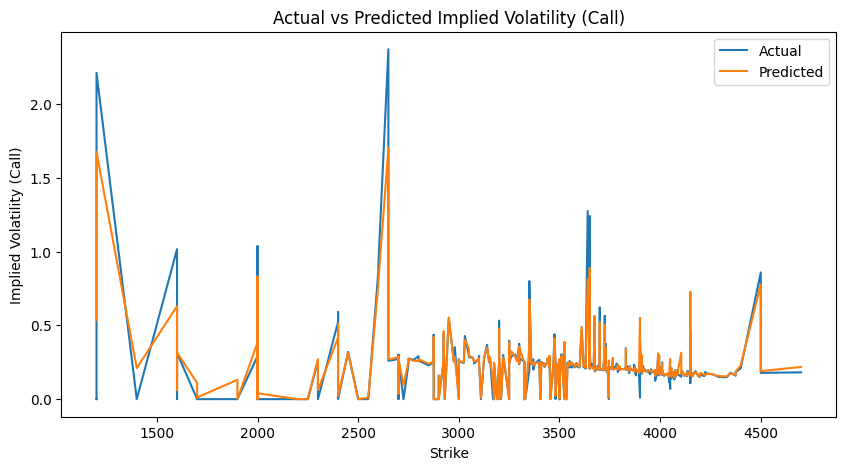

In [285]:
df_sorted = df.sort_values("Strike")

plt.figure(figsize=(10, 5))
plt.plot(df_sorted["Strike"], df_sorted["C_IV"], label="Actual")
plt.plot(df_sorted["Strike"], df_sorted["Predicted_C_IV"], label="Predicted")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility (Call)")
plt.title("Actual vs Predicted Implied Volatility (Call)")
plt.legend()
plt.show()

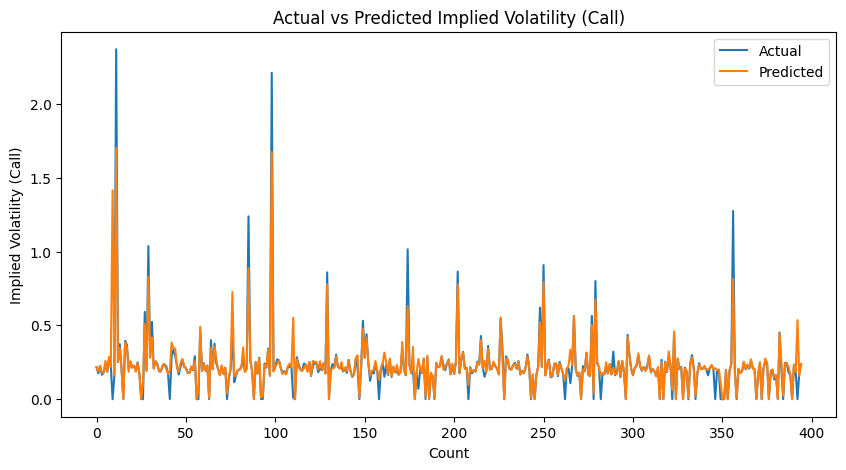

In [281]:
x = range(len(df))
plt.figure(figsize=(10, 5))
plt.plot(x, df["C_IV"], label="Actual")
plt.plot(x, df["Predicted_C_IV"], label="Predicted")
plt.xlabel("Count")
plt.ylabel("Implied Volatility (Call)")
plt.title("Actual vs Predicted Implied Volatility (Call)")
plt.legend()
plt.show()

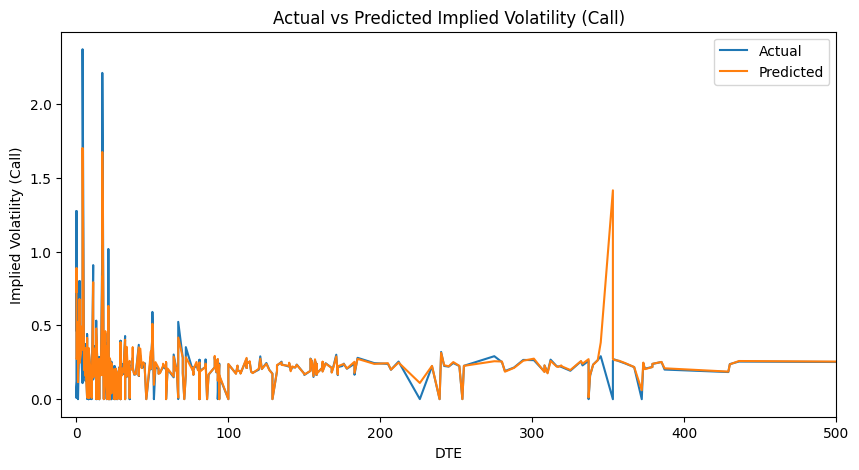

In [292]:
df_sorted = df.sort_values("DTE")
plt.figure(figsize=(10, 5))
plt.plot(df_sorted["DTE"], df_sorted["C_IV"], label="Actual")
plt.plot(df_sorted["DTE"], df_sorted["Predicted_C_IV"], label="Predicted")
plt.xlabel("DTE")
plt.ylabel("Implied Volatility (Call)")
plt.title("Actual vs Predicted Implied Volatility (Call)")
plt.xlim(-10, 500)
plt.legend()
plt.show()

In [282]:
put_X = df[["Quote_Time_Hours", "Underlying_Last", "DTE", "P_Volume", "P_Delta", "P_Gamma", "P_Vega", "P_Theta", "P_Rho", "P_Last", "P_Bid", "P_Ask", "Strike", "P_Bid_Size", "P_Ask_Size"]]
put_y = df["P_IV"]
put_X_train, put_X_test, put_y_train, put_y_test = train_test_split(
    put_X,
    put_y,
    test_size=0.25,
    random_state=42
)
put_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
put_rf.fit(put_X_train, put_y_train)
put_y_test_pred = put_rf.predict(put_X_test)
df["Predicted_P_IV"] = put_rf.predict(put_X)
df
print("MAE:", mean_absolute_error(put_y_test, put_y_test_pred))
print("R²:", r2_score(put_y_test, put_y_test_pred))

MAE: 0.03162705707070713
R²: 0.5854914041975019


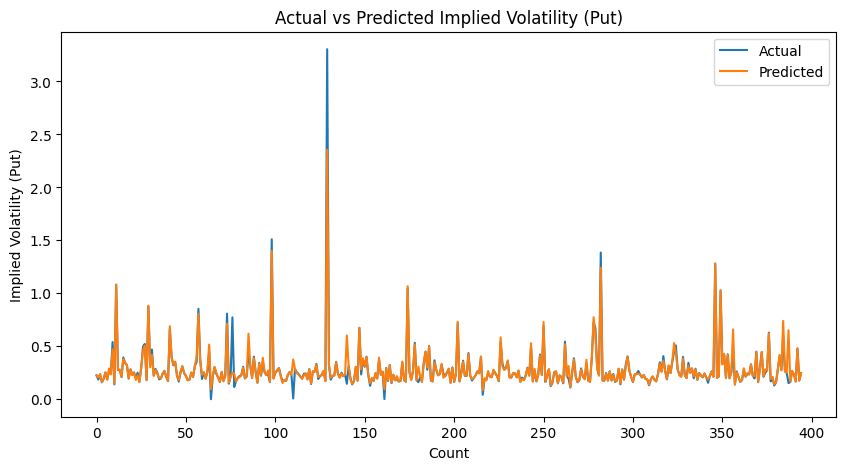

In [283]:
x = range(len(df))
plt.figure(figsize=(10, 5))
plt.plot(x, df["P_IV"], label="Actual")
plt.plot(x, df["Predicted_P_IV"], label="Predicted")
plt.xlabel("Count")
plt.ylabel("Implied Volatility (Put)")
plt.title("Actual vs Predicted Implied Volatility (Put)")
plt.legend()

plt.show()

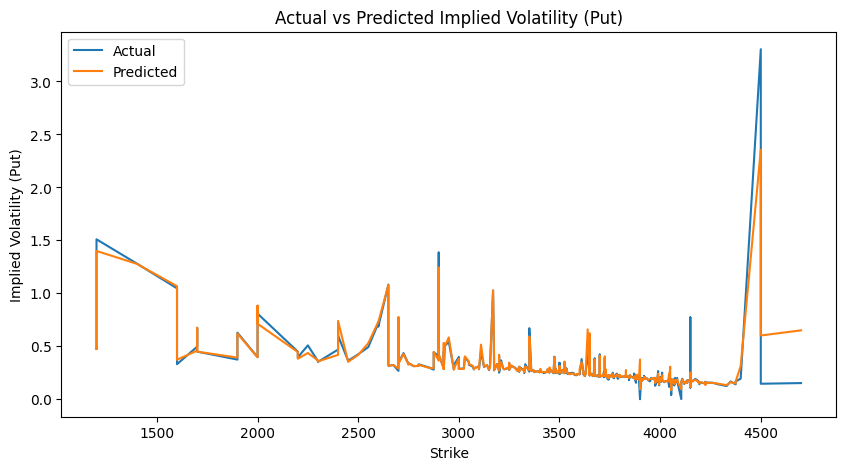

In [286]:
df_sorted = df.sort_values("Strike")

plt.figure(figsize=(10, 5))
plt.plot(df_sorted["Strike"], df_sorted["P_IV"], label="Actual")
plt.plot(df_sorted["Strike"], df_sorted["Predicted_P_IV"], label="Predicted")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility (Put)")
plt.title("Actual vs Predicted Implied Volatility (Put)")
plt.legend()
plt.show()

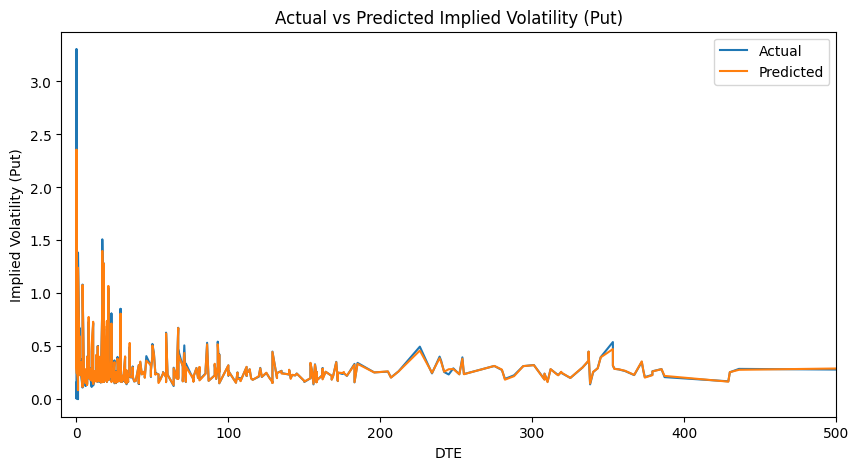

In [ ]:
df_sorted = df.sort_values("DTE")
plt.figure(figsize=(10, 5))
plt.plot(df_sorted["DTE"], df_sorted["P_IV"], label="Actual")
plt.plot(df_sorted["DTE"], df_sorted["Predicted_P_IV"], label="Predicted")
plt.xlabel("DTE")
plt.ylabel("Implied Volatility (Put)")
plt.title("Actual vs Predicted Implied Volatility (Put)")
plt.xlim(-10, 500)
plt.legend()
plt.show()